<a href="https://colab.research.google.com/github/HoaiNam2k5/Lab03_ANN/blob/main/ANN_CIFAR10_Lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Nhận Dạng Ảnh CIFAR-10 Bằng Mạng Nơ-ron Nhân Tạo (ANN)

## Giới thiệu
Trong notebook này,ta sẽ xây dựng một mạng nơ-ron nhân tạo (ANN - Artificial Neural Network) để nhận dạng ảnh trên bộ dữ liệu **CIFAR-10**.

### Các nhãn của CIFAR-10:
| Label | Mô tả |
|-------|--------|
| 0 | airplane (máy bay) |
| 1 | automobile (ô tô) |
| 2 | bird (chim) |
| 3 | cat (mèo) |
| 4 | deer (hươu) |
| 5 | dog (chó) |
| 6 | frog (ếch) |
| 7 | horse (ngựa) |
| 8 | ship (tàu thủy) |
| 9 | truck (xe tải) |

### Các bước thực hiện:
1. Cài đặt và import thư viện
2. Tải và khám phá dữ liệu CIFAR-10
3. Tiền xử lý dữ liệu
4. Xây dựng mô hình ANN
5. Huấn luyện mô hình
6. Đánh giá mô hình
7. Dự đoán và trực quan hóa kết quả

---
## Bước 1: Import Thư Viện
Import các thư viện cần thiết bao gồm TensorFlow/Keras, NumPy, Matplotlib.

In [1]:
# Import các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Kiểm tra phiên bản
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

# Kiểm tra GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n GPU available: {gpus[0].name}")
else:
    print("\n No GPU found, using CPU")

# Seed để tái tạo kết quả
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0
NumPy version: 2.0.2

✅ GPU available: /physical_device:GPU:0


---
## Bước 2: Tải và Khám Phá Dữ Liệu CIFAR-10

CIFAR-10 là bộ dữ liệu gồm **60.000 ảnh màu** kích thước **32×32 pixels**, chia thành:
- **50.000 ảnh** dùng để huấn luyện (train)
- **10.000 ảnh** dùng để kiểm tra (test)
- **10 lớp** (classes), mỗi lớp có 6.000 ảnh

In [2]:
# Tải bộ dữ liệu CIFAR-10 từ Keras
print("Đang tải dữ liệu CIFAR-10...")
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Danh sách tên các nhãn
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# In thông tin cơ bản về dữ liệu
print(f"\n📊 Thông tin dữ liệu:")
print(f"  - Tập huấn luyện (train): {X_train.shape} ảnh")
print(f"  - Tập kiểm tra  (test) : {X_test.shape} ảnh")
print(f"  - Nhãn train: {y_train.shape}")
print(f"  - Nhãn test : {y_test.shape}")
print(f"  - Kích thước ảnh: {X_train.shape[1]}x{X_train.shape[2]} pixels, {X_train.shape[3]} kênh màu (RGB)")
print(f"  - Giá trị pixel: min={X_train.min()}, max={X_train.max()}")

Đang tải dữ liệu CIFAR-10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

📊 Thông tin dữ liệu:
  - Tập huấn luyện (train): (50000, 32, 32, 3) ảnh
  - Tập kiểm tra  (test) : (10000, 32, 32, 3) ảnh
  - Nhãn train: (50000, 1)
  - Nhãn test : (10000, 1)
  - Kích thước ảnh: 32x32 pixels, 3 kênh màu (RGB)
  - Giá trị pixel: min=0, max=255


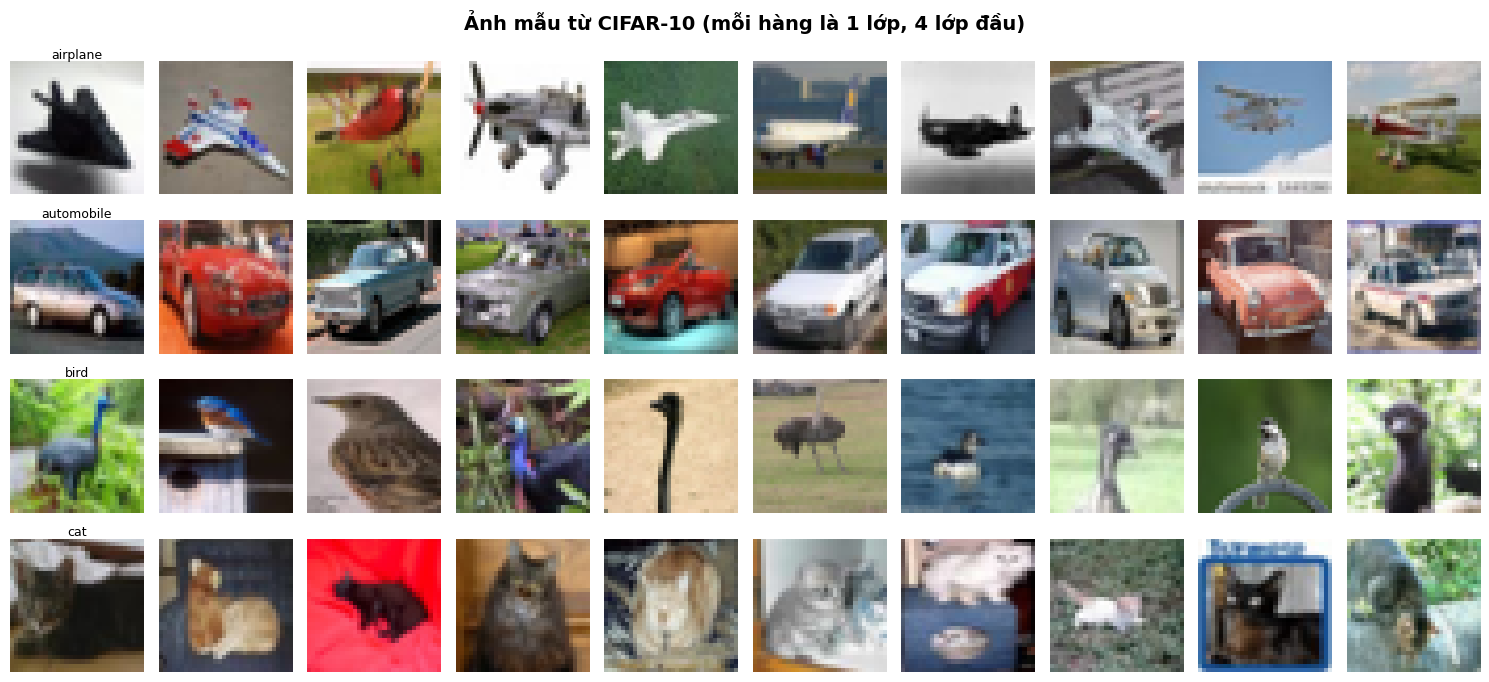

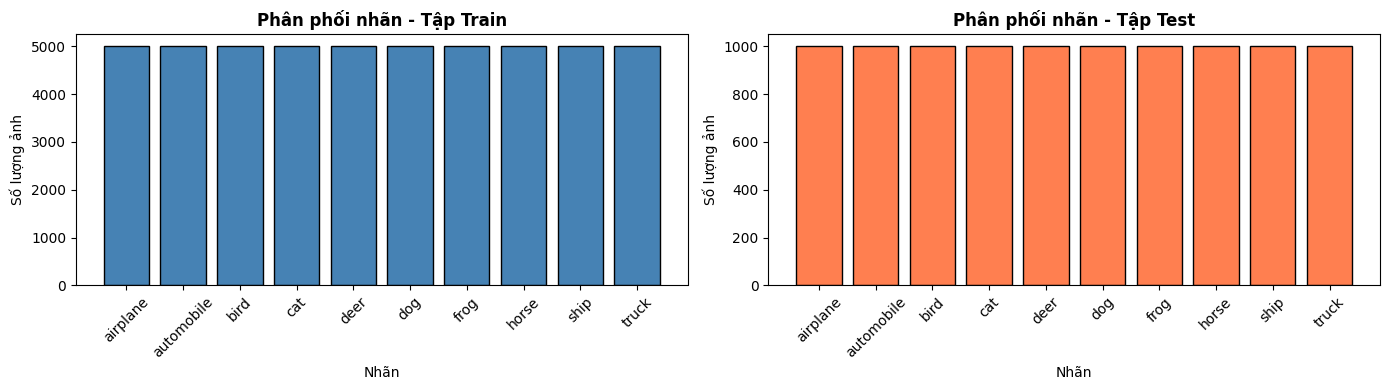

✅ Dữ liệu được phân phối đều - mỗi lớp có đúng 5000 ảnh train và 1000 ảnh test


In [3]:
# Trực quan hóa một số ảnh mẫu từ tập dữ liệu
fig, axes = plt.subplots(4, 10, figsize=(15, 7))
fig.suptitle('Ảnh mẫu từ CIFAR-10 (mỗi hàng là 1 lớp, 4 lớp đầu)', fontsize=14, fontweight='bold')

# Hiển thị 4 nhãn đầu, mỗi nhãn 10 ảnh
for label in range(4):
    # Lấy các chỉ số của ảnh thuộc nhãn này
    indices = np.where(y_train.flatten() == label)[0][:10]
    for j, idx in enumerate(indices):
        axes[label, j].imshow(X_train[idx])
        axes[label, j].axis('off')
        if j == 0:
            axes[label, j].set_title(f'{class_names[label]}', fontsize=9, pad=2)

plt.tight_layout()
plt.show()

# Phân phối số lượng ảnh theo từng lớp
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Train set
unique_train, counts_train = np.unique(y_train, return_counts=True)
ax1.bar(class_names, counts_train, color='steelblue', edgecolor='black')
ax1.set_title('Phân phối nhãn - Tập Train', fontsize=12, fontweight='bold')
ax1.set_xlabel('Nhãn')
ax1.set_ylabel('Số lượng ảnh')
ax1.tick_params(axis='x', rotation=45)

# Test set
unique_test, counts_test = np.unique(y_test, return_counts=True)
ax2.bar(class_names, counts_test, color='coral', edgecolor='black')
ax2.set_title('Phân phối nhãn - Tập Test', fontsize=12, fontweight='bold')
ax2.set_xlabel('Nhãn')
ax2.set_ylabel('Số lượng ảnh')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print("✅ Dữ liệu được phân phối đều - mỗi lớp có đúng 5000 ảnh train và 1000 ảnh test")

---
## Bước 3: Tiền Xử Lý Dữ Liệu (Preprocessing)

Trước khi đưa dữ liệu vào mô hình ANN, chúng ta cần:
1. **Chuẩn hóa (Normalize)**: Chuyển giá trị pixel từ [0, 255] về [0, 1]
2. **Làm phẳng (Flatten)**: Chuyển ảnh 32×32×3 thành vector 1D có 3072 phần tử
3. **One-hot encoding**: Chuyển nhãn số nguyên thành vector nhị phân

In [4]:
# ---- BƯỚC 3.1: Chuẩn hóa giá trị pixel ----
# Chia cho 255.0 để đưa giá trị pixel về khoảng [0, 1]
# Điều này giúp gradient descent hội tụ nhanh hơn
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

print(f"Trước chuẩn hóa: min={X_train.min()}, max={X_train.max()}")
print(f"Sau chuẩn hóa : min={X_train_norm.min():.2f}, max={X_train_norm.max():.2f}")

# ---- BƯỚC 3.2: Làm phẳng ảnh (Flatten) ----
# ANN (Fully Connected) yêu cầu đầu vào là vector 1D
# 32 x 32 x 3 = 3072 đặc trưng
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat  = X_test_norm.reshape(X_test_norm.shape[0], -1)

print(f"\nShape sau khi flatten:")
print(f"  X_train: {X_train_flat.shape}  (50000 ảnh x 3072 đặc trưng)")
print(f"  X_test : {X_test_flat.shape}   (10000 ảnh x 3072 đặc trưng)")

# ---- BƯỚC 3.3: One-hot encoding nhãn ----
# Ví dụ: nhãn 3 (cat) -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print(f"\nShape nhãn sau one-hot encoding:")
print(f"  y_train: {y_train_cat.shape}")
print(f"  y_test : {y_test_cat.shape}")
print(f"\nVí dụ nhãn gốc: {y_train[0][0]} ({class_names[y_train[0][0]]})")
print(f"Sau one-hot    : {y_train_cat[0]}")

Trước chuẩn hóa: min=0, max=255
Sau chuẩn hóa : min=0.00, max=1.00

Shape sau khi flatten:
  X_train: (50000, 3072)  (50000 ảnh x 3072 đặc trưng)
  X_test : (10000, 3072)   (10000 ảnh x 3072 đặc trưng)

Shape nhãn sau one-hot encoding:
  y_train: (50000, 10)
  y_test : (10000, 10)

Ví dụ nhãn gốc: 6 (frog)
Sau one-hot    : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


---
## Bước 4: Xây Dựng Mô Hình ANN

### Kiến trúc mạng ANN:
```
Input Layer  : 3072 neurons (32×32×3 pixels)
    ↓
Hidden Layer 1: 1024 neurons + BatchNorm + Dropout(0.4)
    ↓
Hidden Layer 2: 512 neurons + BatchNorm + Dropout(0.3)
    ↓
Hidden Layer 3: 256 neurons + BatchNorm + Dropout(0.3)
    ↓
Hidden Layer 4: 128 neurons + BatchNorm + Dropout(0.2)
    ↓
Output Layer : 10 neurons (softmax - xác suất cho 10 lớp)
```

**Giải thích các thành phần:**
- **Dense**: Lớp fully-connected (kết nối đầy đủ)
- **ReLU**: Hàm kích hoạt `f(x) = max(0, x)` - nhanh, hiệu quả
- **BatchNormalization**: Chuẩn hóa đầu ra từng lớp giúp huấn luyện ổn định hơn
- **Dropout**: Ngẫu nhiên tắt một số neurons để tránh overfitting
- **Softmax**: Chuyển output thành xác suất cho bài toán phân loại nhiều lớp

In [5]:
# ---- Xây dựng kiến trúc ANN ----
def build_ann_model(input_dim=3072, num_classes=10):
    """
    Xây dựng mô hình ANN nhiều lớp cho bài toán phân loại CIFAR-10.

    Args:
        input_dim  : Số chiều đầu vào (32*32*3 = 3072)
        num_classes: Số lớp phân loại (10)
    Returns:
        model: Keras Sequential model
    """
    model = models.Sequential(name='ANN_CIFAR10')

    # ---- Input Layer ----
    model.add(layers.Input(shape=(input_dim,)))

    # ---- Hidden Layer 1: 1024 neurons ----
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.BatchNormalization())   # Chuẩn hóa để ổn định huấn luyện
    model.add(layers.Dropout(0.4))           # Bỏ 40% neurons ngẫu nhiên khi train

    # ---- Hidden Layer 2: 512 neurons ----
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    # ---- Hidden Layer 3: 256 neurons ----
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    # ---- Hidden Layer 4: 128 neurons ----
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.2))

    # ---- Output Layer: 10 neurons (softmax) ----
    # Softmax cho ra xác suất của 10 lớp, tổng = 1.0
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Khởi tạo mô hình
model = build_ann_model(input_dim=3072, num_classes=10)

# In tóm tắt kiến trúc mô hình
model.summary()

Model: "ANN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,746 (14.67 MB)

 Trainable params: 3,840,906 (14.65 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [6]:
# ---- Compile mô hình ----
# - optimizer: Adam - thuật toán tối ưu hóa hiệu quả, tự điều chỉnh learning rate
# - loss: categorical_crossentropy - hàm mất mát cho phân loại nhiều lớp (one-hot)
# - metrics: accuracy - đo lường hiệu suất trên tập validation

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Mô hình đã được compile!")
print(f"   Optimizer   : Adam (lr=0.001)")
print(f"   Loss        : categorical_crossentropy")
print(f"   Metrics     : accuracy")
print(f"   Total params: {model.count_params():,}")

✅ Mô hình đã được compile!
   Optimizer   : Adam (lr=0.001)
   Loss        : categorical_crossentropy
   Metrics     : accuracy
   Total params: 3,844,746


---
## Bước 5: Huấn Luyện Mô Hình

### Các kỹ thuật sử dụng:
- **EarlyStopping**: Dừng huấn luyện sớm nếu val_loss không cải thiện sau 10 epochs
- **ReduceLROnPlateau**: Giảm learning rate khi val_loss không cải thiện
- **ModelCheckpoint**: Lưu model tốt nhất dựa trên val_accuracy

In [7]:
# ---- Định nghĩa Callbacks ----

# 1. EarlyStopping: dừng khi val_loss không giảm sau 10 epoch
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,  # Khôi phục trọng số tốt nhất
    verbose=1
)

# 2. ReduceLROnPlateau: giảm learning rate khi val_loss không cải thiện
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # Giảm lr xuống còn 50%
    patience=5,       # Chờ 5 epoch trước khi giảm
    min_lr=1e-6,      # Ngưỡng lr tối thiểu
    verbose=1
)

# 3. ModelCheckpoint: lưu model tốt nhất
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='best_ann_cifar10.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

callbacks = [early_stopping, reduce_lr, checkpoint]
print("✅ Đã thiết lập callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint")

✅ Đã thiết lập callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [8]:
# ---- Huấn luyện mô hình ----
print("🚀 Bắt đầu huấn luyện...")
print("="*60)

history = model.fit(
    X_train_flat, y_train_cat,
    epochs=100,             # Số epoch tối đa (EarlyStopping sẽ dừng sớm)
    batch_size=256,         # Số ảnh xử lý mỗi lần cập nhật gradient
    validation_split=0.1,   # Dùng 10% dữ liệu train để validation (5000 ảnh)
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Huấn luyện hoàn thành!")
print(f"   Số epochs thực tế: {len(history.history['loss'])}")

🚀 Bắt đầu huấn luyện...
Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.2901 - loss: 2.0768 - val_accuracy: 0.3684 - val_loss: 1.7748 - learning_rate: 0.0010
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3640 - loss: 1.7749 - val_accuracy: 0.3160 - val_loss: 1.9561 - learning_rate: 0.0010
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3984 - loss: 1.6773 - val_accuracy: 0.3230 - val_loss: 1.9063 - learning_rate: 0.0010
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4170 - loss: 1.6261 - val_accuracy: 0.3714 - val_loss: 1.7704 - learning_rate: 0.0010
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4311 - loss: 1.5961 - val_accuracy: 0.3626 - val_loss: 1.7935 - learning_rate: 0.0010
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4358 - loss: 1.5708 - val_accuracy: 0.3644 - val_loss: 1.7665 - learning_rate: 0.0010
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - a

---
## Bước 6: Đánh Giá Mô Hình

Chúng ta sẽ đánh giá mô hình qua:
1. **Đường cong học (Learning Curves)**: Theo dõi loss và accuracy theo epoch
2. **Độ chính xác tổng thể** trên tập test
3. **Classification Report**: Precision, Recall, F1-score cho từng lớp
4. **Confusion Matrix**: Ma trận nhầm lẫn

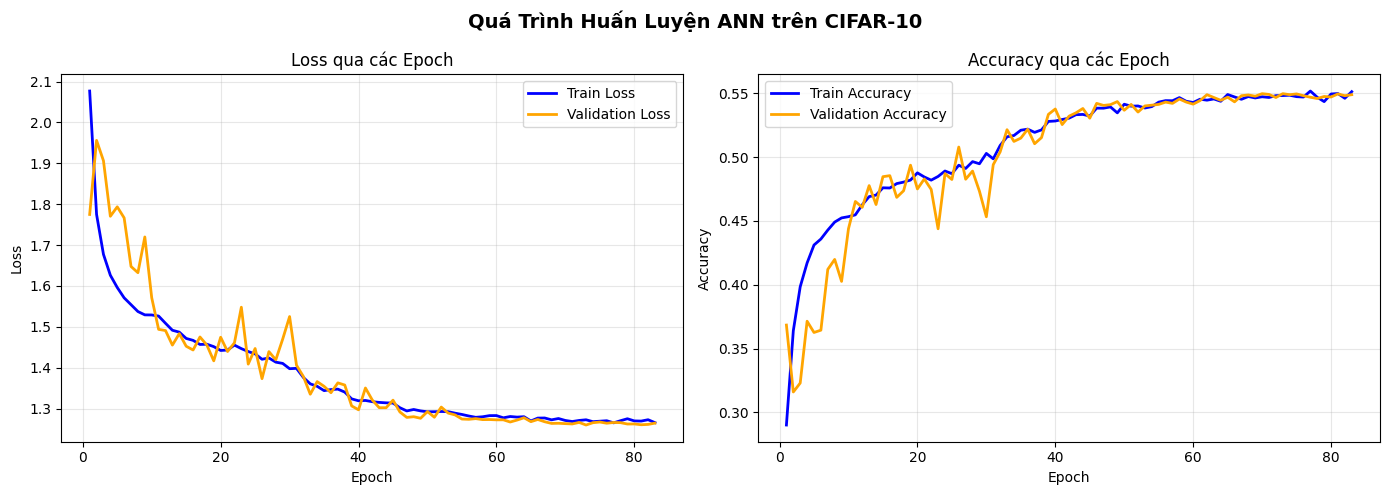

In [9]:
# ---- Vẽ đường cong học (Learning Curves) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Quá Trình Huấn Luyện ANN trên CIFAR-10', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history.history['loss']) + 1)

# Biểu đồ 1: Loss
axes[0].plot(epochs_range, history.history['loss'],     label='Train Loss',      color='blue',   linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
axes[0].set_title('Loss qua các Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Biểu đồ 2: Accuracy
axes[1].plot(epochs_range, history.history['accuracy'],     label='Train Accuracy',      color='blue',   linewidth=2)
axes[1].plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
axes[1].set_title('Accuracy qua các Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ---- Đánh giá trên tập Test ----
print("📊 Đánh giá mô hình trên tập Test:")
print("="*50)

test_loss, test_acc = model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"  Test Loss    : {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Dự đoán trên tập test
y_pred_proba = model.predict(X_test_flat, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)  # Lấy lớp có xác suất cao nhất
y_true       = y_test.flatten()

print(f"\n📋 Classification Report:")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

📊 Đánh giá mô hình trên tập Test:
  Test Loss    : 1.2811
  Test Accuracy: 0.5426 (54.26%)

📋 Classification Report:
              precision    recall  f1-score   support

    airplane       0.60      0.61      0.61      1000
  automobile       0.69      0.64      0.66      1000
        bird       0.42      0.42      0.42      1000
         cat       0.38      0.33      0.35      1000
        deer       0.47      0.49      0.48      1000
         dog       0.50      0.39      0.44      1000
        frog       0.50      0.68      0.57      1000
       horse       0.60      0.58      0.59      1000
        ship       0.62      0.71      0.66      1000
       truck       0.64      0.57      0.60      1000

    accuracy                           0.54     10000
   macro avg       0.54      0.54      0.54     10000
weighted avg       0.54      0.54      0.54     10000



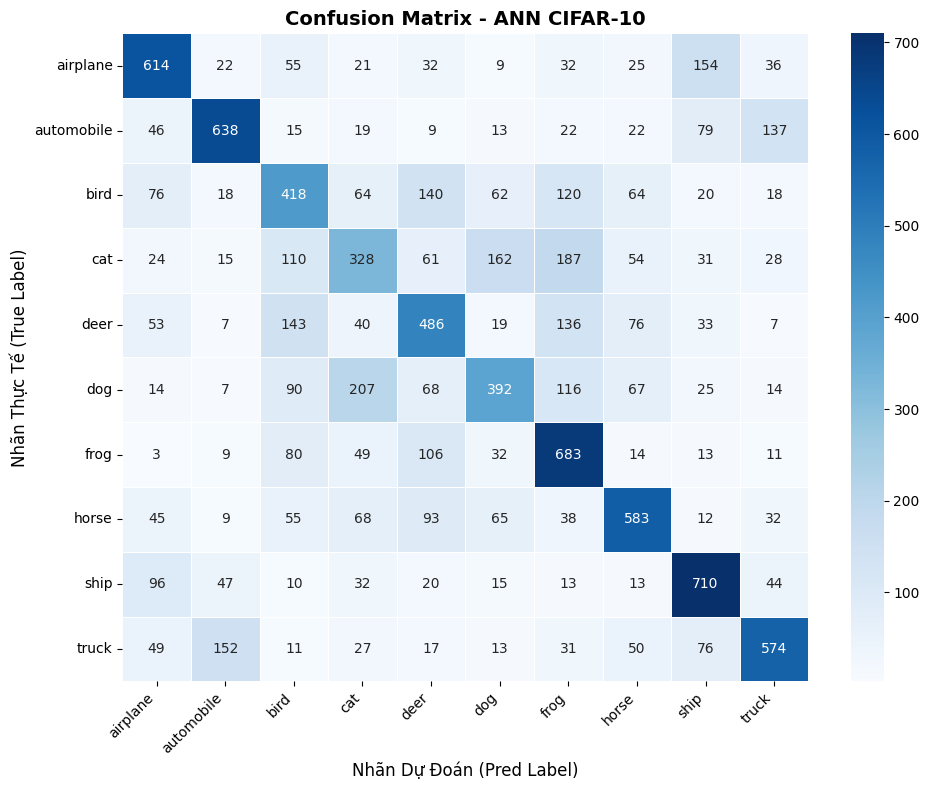


📌 Accuracy từng lớp:
-----------------------------------
  airplane    :  61.4% ████████████
  automobile  :  63.8% ████████████
  bird        :  41.8% ████████
  cat         :  32.8% ██████
  deer        :  48.6% █████████
  dog         :  39.2% ███████
  frog        :  68.3% █████████████
  horse       :  58.3% ███████████
  ship        :  71.0% ██████████████
  truck       :  57.4% ███████████


In [11]:
# ---- Vẽ Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title('Confusion Matrix - ANN CIFAR-10', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn Thực Tế (True Label)',  fontsize=12)
plt.xlabel('Nhãn Dự Đoán (Pred Label)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Accuracy từng lớp
print("\n📌 Accuracy từng lớp:")
print("-"*35)
for i, name in enumerate(class_names):
    class_acc = cm[i, i] / cm[i].sum() * 100
    bar = '█' * int(class_acc / 5)
    print(f"  {name:12s}: {class_acc:5.1f}% {bar}")

---
## Bước 7: Dự Đoán và Trực Quan Hóa Kết Quả

Hiển thị một số ảnh dự đoán đúng và sai để phân tích lỗi của mô hình.

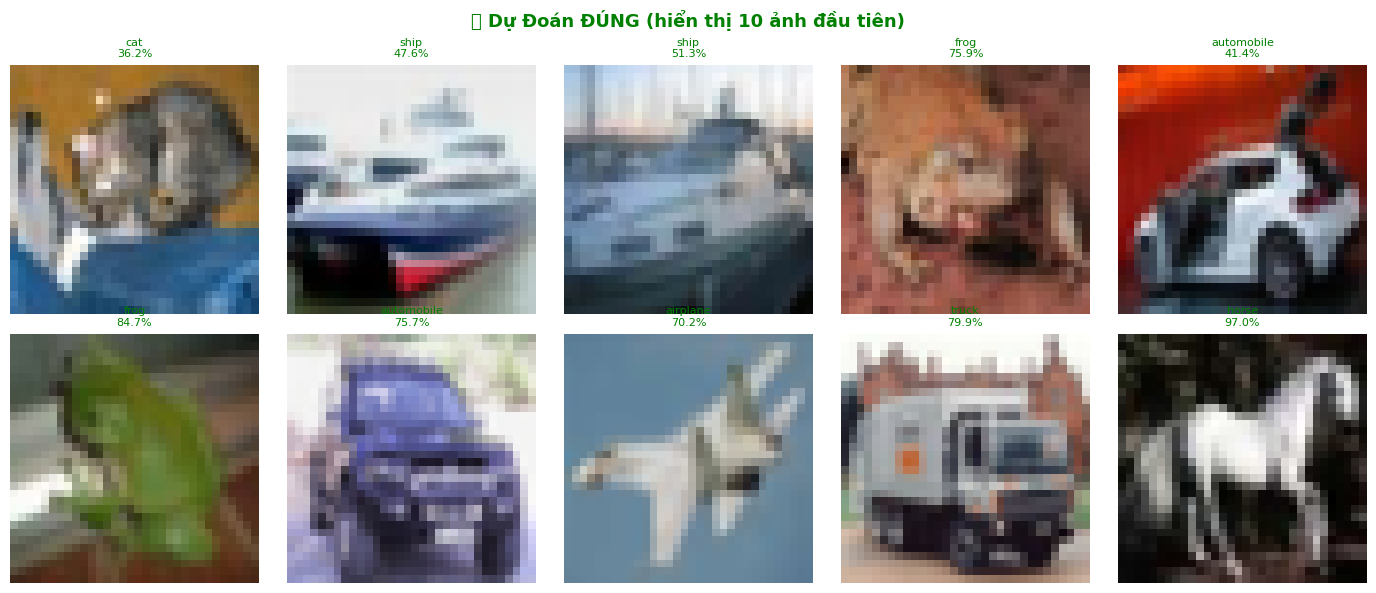

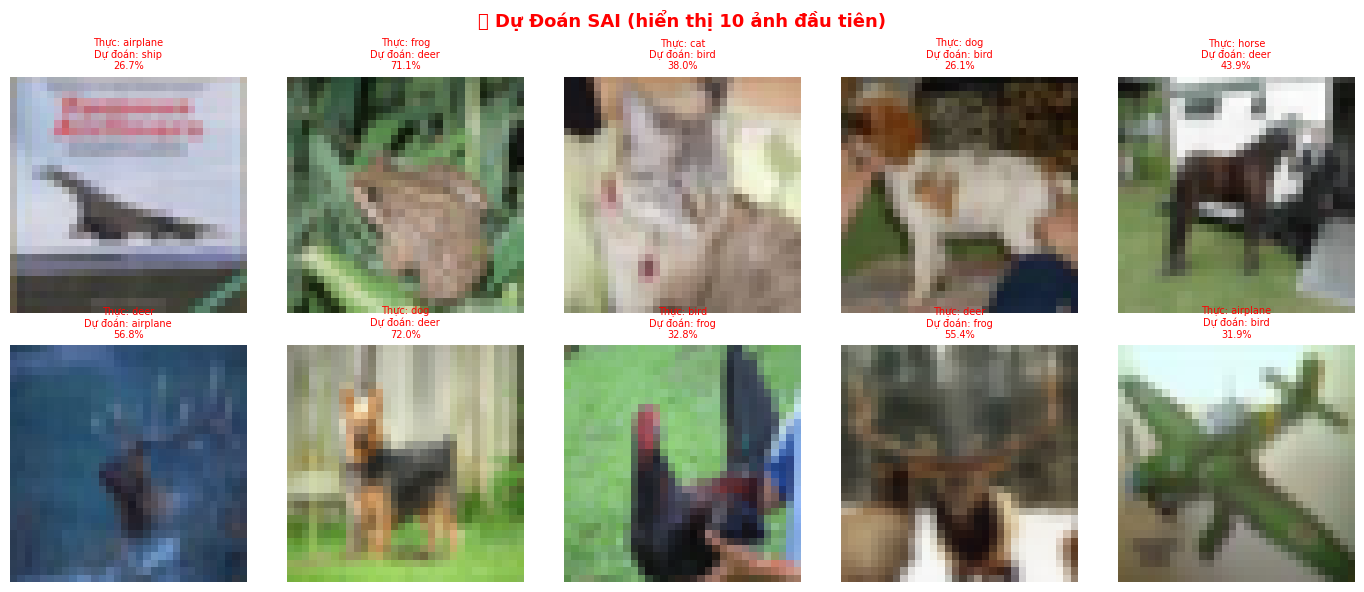

In [12]:
# ---- Hiển thị ảnh dự đoán đúng và sai ----
def plot_predictions(X, y_true, y_pred, y_pred_proba, class_names, n=10, correct=True):
    """
    Vẽ ảnh dự đoán đúng hoặc sai của mô hình.

    Args:
        correct: True = hiển thị ảnh đúng, False = hiển thị ảnh sai
    """
    # Lọc theo đúng/sai
    if correct:
        mask    = (y_pred == y_true)
        title   = f'✅ Dự Đoán ĐÚNG (hiển thị {n} ảnh đầu tiên)'
        color   = 'green'
    else:
        mask    = (y_pred != y_true)
        title   = f'❌ Dự Đoán SAI (hiển thị {n} ảnh đầu tiên)'
        color   = 'red'

    indices = np.where(mask)[0][:n]
    if len(indices) == 0:
        print("Không tìm thấy ảnh phù hợp!")
        return

    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    fig.suptitle(title, fontsize=13, fontweight='bold', color=color)

    for i, idx in enumerate(indices):
        row, col = divmod(i, 5)
        ax = axes[row][col]
        ax.imshow(X[idx])
        ax.axis('off')
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        conf       = y_pred_proba[idx][y_pred[idx]] * 100
        if correct:
            ax.set_title(f'{pred_label}\n{conf:.1f}%', fontsize=8, color='green')
        else:
            ax.set_title(f'Thực: {true_label}\nDự đoán: {pred_label}\n{conf:.1f}%', fontsize=7, color='red')

    plt.tight_layout()
    plt.show()

# Hiển thị ảnh dự đoán ĐÚNG
plot_predictions(X_test, y_true, y_pred, y_pred_proba, class_names, n=10, correct=True)

# Hiển thị ảnh dự đoán SAI
plot_predictions(X_test, y_true, y_pred, y_pred_proba, class_names, n=10, correct=False)


--- Ảnh index 2656 | Nhãn thực: truck ---


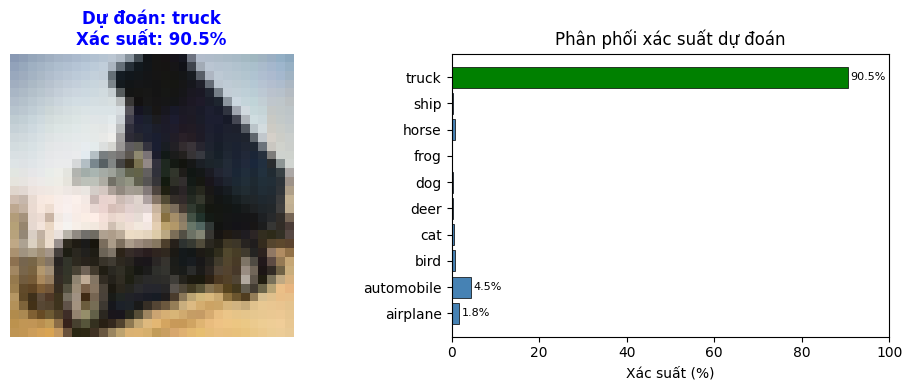

   Kết quả: ✅ ĐÚNG

--- Ảnh index 445 | Nhãn thực: horse ---


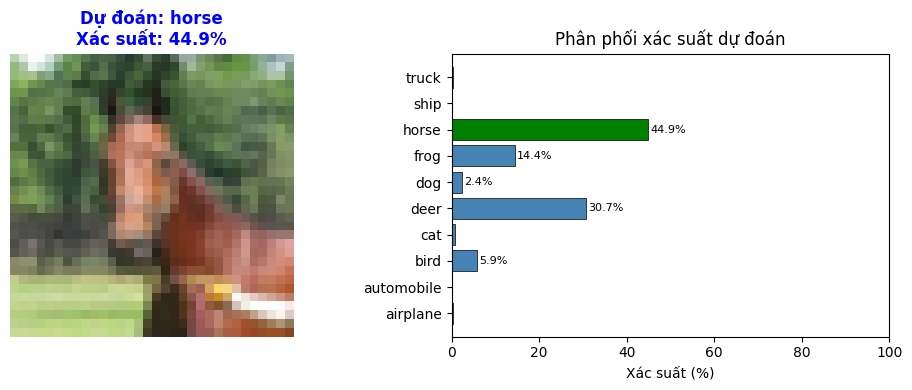

   Kết quả: ✅ ĐÚNG

--- Ảnh index 9505 | Nhãn thực: cat ---


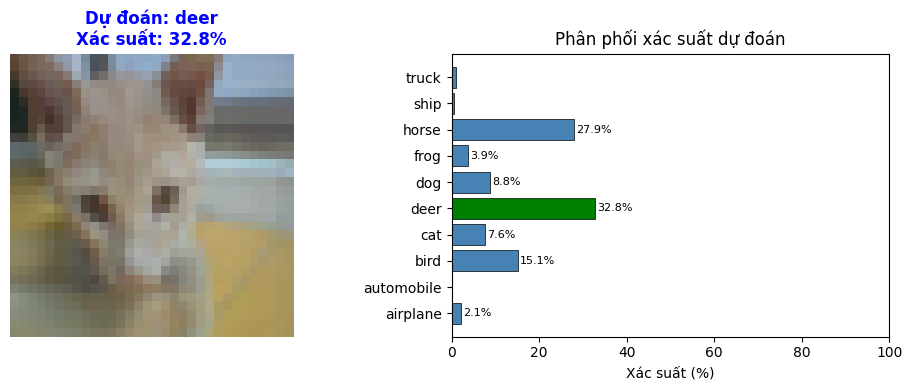

   Kết quả: ❌ SAI


In [13]:
# ---- Dự đoán ảnh đơn lẻ ----
def predict_single_image(model, image, class_names):
    """
    Dự đoán nhãn của một ảnh đơn và hiển thị xác suất.
    """
    # Tiền xử lý
    img_norm  = image.astype('float32') / 255.0
    img_flat  = img_norm.flatten().reshape(1, -1)

    # Dự đoán
    proba     = model.predict(img_flat, verbose=0)[0]
    pred_idx  = np.argmax(proba)

    # Vẽ ảnh và biểu đồ xác suất
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title(f'Dự đoán: {class_names[pred_idx]}\nXác suất: {proba[pred_idx]*100:.1f}%',
                  fontsize=12, fontweight='bold', color='blue')

    colors = ['green' if i == pred_idx else 'steelblue' for i in range(len(class_names))]
    bars   = ax2.barh(class_names, proba * 100, color=colors, edgecolor='black', linewidth=0.5)
    ax2.set_xlabel('Xác suất (%)')
    ax2.set_title('Phân phối xác suất dự đoán')
    ax2.set_xlim(0, 100)

    # Thêm nhãn giá trị
    for bar, val in zip(bars, proba * 100):
        if val > 1:
            ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()
    return pred_idx, proba

# Thử dự đoán 3 ảnh ngẫu nhiên từ tập test
np.random.seed(123)
random_indices = np.random.choice(len(X_test), 3, replace=False)

for idx in random_indices:
    print(f"\n--- Ảnh index {idx} | Nhãn thực: {class_names[y_true[idx]]} ---")
    pred_idx, proba = predict_single_image(model, X_test[idx], class_names)
    status = "✅ ĐÚNG" if pred_idx == y_true[idx] else "❌ SAI"
    print(f"   Kết quả: {status}")

---
## Tổng Kết

### Kết quả đạt được:

| Thành phần | Chi tiết |
|-----------|----------|
| Mô hình | ANN (Fully Connected) 4 lớp ẩn |
| Tổng tham số | ~3.7 triệu parameters |
| Input | 3072 đặc trưng (32×32×3 flatten) |
| Kỹ thuật chống overfitting | Dropout + BatchNormalization |
| Optimizer | Adam (lr=0.001) |
| Dataset | CIFAR-10 (50K train / 10K test) |

### Nhận xét:
- ANN (MLP) đạt ~**50-55% accuracy** trên CIFAR-10 - đây là kết quả điển hình với mạng fully connected
- CIFAR-10 là bài toán khó với ANN vì ảnh màu 32×32 có nhiều biến thể không gian
- **CNN (Convolutional Neural Network)** sẽ cho kết quả tốt hơn nhiều (~90%+) vì khai thác được cấu trúc không gian của ảnh

### Hướng cải tiến:
1. Dùng **CNN** thay ANN để tận dụng cấu trúc không gian
2. Tăng **Data Augmentation** (lật ảnh, xoay, crop...)
3. Thử **Transfer Learning** với VGG16, ResNet, EfficientNet
4. Tăng số lớp/neurons hoặc dùng **Residual connections**

In [14]:
# ---- In kết quả cuối cùng ----
print("="*55)
print("         KẾT QUẢ CUỐI CÙNG - ANN CIFAR-10")
print("="*55)
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Epochs chạy   : {len(history.history['loss'])}")
print(f"  Total params  : {model.count_params():,}")
print("="*55)
print("\n📁 Model tốt nhất đã được lưu: best_ann_cifar10.keras")

         KẾT QUẢ CUỐI CÙNG - ANN CIFAR-10
  Test Accuracy : 54.26%
  Test Loss     : 1.2811
  Epochs chạy   : 83
  Total params  : 3,844,746

📁 Model tốt nhất đã được lưu: best_ann_cifar10.keras
